# Figure 1

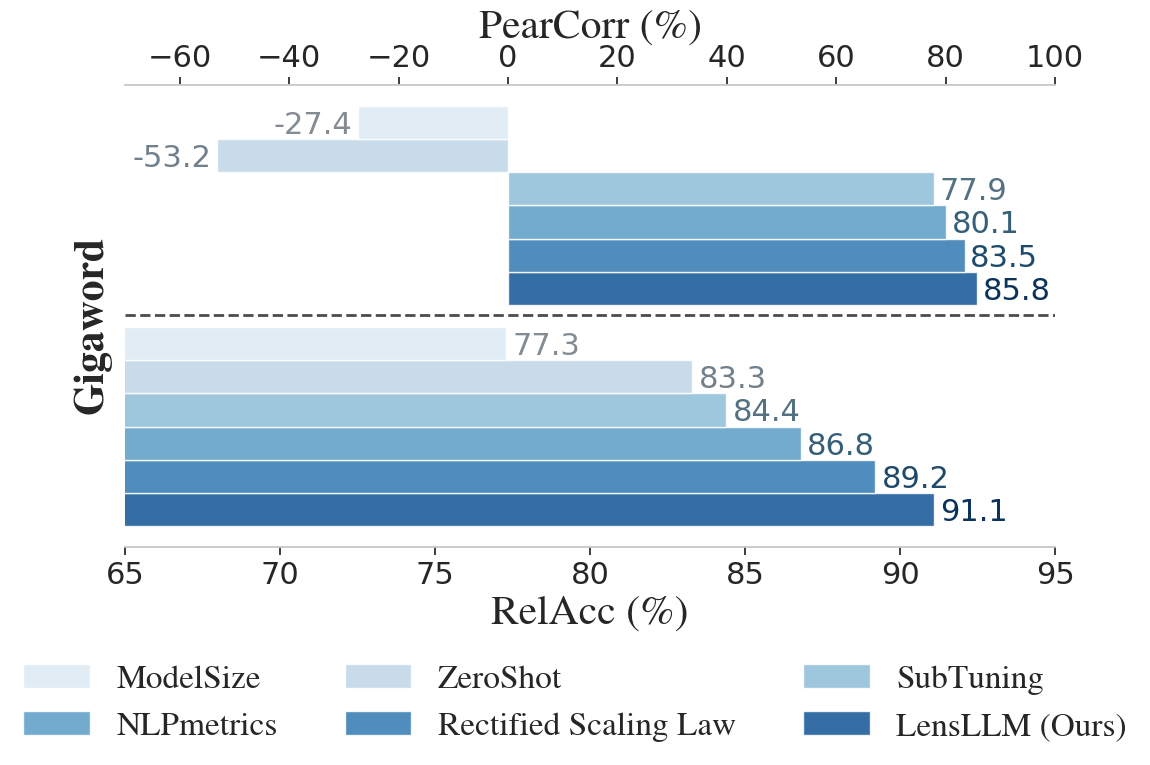

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import seaborn as sns
from matplotlib import rcParams

def adjust_saturation(color, saturation=0.75):
    r, g, b, a = to_rgba(color)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    r = gray + saturation * (r - gray)
    g = gray + saturation * (g - gray)
    b = gray + saturation * (b - gray)
    return (r, g, b, a)

def adjust_lightness(color, amount=0.5):
    """
    Adjust the lightness of the given color. 
    An amount less than 1 will darken the color, and an amount greater than 1 will lighten the color.

    Parameters:
    color (str or tuple): Matplotlib color string or RGBA tuple.
    amount (float): Factor to adjust the lightness. Default is 0.5 (darken).

    Returns:
    tuple: Adjusted color in RGBA format.
    """
    r, g, b, a = to_rgba(color)
    # Blend with black
    r = r * amount
    g = g * amount
    b = b * amount
    return (r, g, b, a)

# Set the style and font settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'DejaVu Sans'
# Set the global font family to Nimbus Roman
# rcParams['font.family'] = 'Nimbus Roman'

# Data preparation (same as before)
datasets = ['Gigaword']
methods = ['LensLLM (Ours)', 'Rectified Scaling Law', 'NLPmetrics', 'SubTuning', 'ZeroShot', 'ModelSize']
pearcorr_data = np.array([
    [85.8, 83.5, 80.1, 77.9, -53.2, -27.4]
])
relacc_data = np.array([
    [91.1, 89.2, 86.8, 84.4, 83.3, 77.3]
])

# Create figure and axes - Changed to vertical arrangement
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))  # Adjusted height to 16
fig, ax1 = plt.subplots(figsize=(12, 6))  # Single combined plot
ax2 = ax1.twiny()  # Create secondary x-axis
fig.patch.set_facecolor('white')

# Bar height and positions
bar_height = 0.15
y = np.arange(len(datasets))[::-1]
colors = ['#0D47A1',    # Very dark blue
          '#1976D2',    # Dark blue
          '#2196F3',    # Medium blue
          '#64B5F6',    # Light blue
          '#90CAF9',    # Lighter blue
          '#BBDEFB']
colors = ['#6A94AF',  # Soft Steel Blue
          '#A4C3D9',  # Light Blue-Grey
          '#BFD4E2',  # Muted Sky Blue
          '#8BAEC7',  # Slightly Vibrant Blue
          '#4F81A5',  # Medium Warm Blue
          '#3B5A73']  # Deep Slate Blue
colors = reversed(sns.color_palette("Blues", len(methods)))

colors = [adjust_saturation(color, 0.9) for color in colors]
text_colors = [adjust_lightness(color, 0.6) for color in colors]

# Plot PearCorr horizontally
legend_handles = []
for i, (method, color, text_color) in enumerate(zip(methods, colors, text_colors)):
    bars = ax1.barh(y + i*bar_height + 1, pearcorr_data[::-1, i], bar_height,
                   label=method, color=color, alpha=0.85)
    if i == 0:
        legend_handles.append(bars)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax1.text(width + np.sign(width)*1, bar.get_y() + bar.get_height()/2 - 0.01,
                f'{width:.1f}',
                ha='left' if width > 0 else 'right', va='center', color=text_color,
                fontsize=22)

# Plot RelAcc horizontally
for i, (method, color, text_color) in enumerate(zip(methods, colors, text_colors)):
    bars = ax2.barh(y + i*bar_height, relacc_data[::-1, i], bar_height,
                   label=method, color=color, alpha=0.85)
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.2, bar.get_y() + bar.get_height()/2 - 0.01,
                f'{width:.1f}',
                ha='left', va='center', color=text_color,
                fontsize=22)

# Set y-axis labels for both plots
ax1.set_yticks(y + 2.5*bar_height + 0.8)
ax1.set_yticklabels(datasets[::-1], fontsize=30, fontweight='bold', fontfamily='Nimbus Roman', rotation=90)
# ax2.set_yticks(y + 2.5*bar_height + 0.5)
# ax2.set_yticklabels(datasets[::-1], fontsize=30, fontweight='bold', fontfamily='Nimbus Roman')

# Set axis limits
ax1.set_xlim(-70, 100)
ax2.set_xlim(65, 95)

ax1.xaxis.set_label_position('top')  # Move label to the top
ax1.xaxis.tick_top()  # Move ticks to the top
ax2.xaxis.set_label_position('bottom')  # Keep label at the bottom
ax2.xaxis.tick_bottom()  # Keep ticks at the bottom

# Set titles and labels
for ax, title, xlabel in zip([ax1, ax2], ['Pearson Correlation Coefficient', 'Relative Accuracy'],
                     ['PearCorr (%)', 'RelAcc (%)']):
    # ax.set_title(title, fontsize=30, fontfamily='Nimbus Roman')
    ax.set_xlabel(xlabel, fontsize=30, fontfamily='Nimbus Roman')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', which='major', labelsize=22)
    
ax1.axhline(y= (bar_height * len(methods)) - 0.02, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Create legend
rcParams['font.family'] = 'Nimbus Roman'

handles_and_labels = list(zip(
    [bar[0] for bar in legend_handles] + [bars[0] for bars in ax2.containers[1:]],
    methods
))
# Reorder handles and labels for left-to-right row-first order
handles_and_labels = sorted(handles_and_labels, key=lambda x: methods.index(x[1]) // 3 + 3 * (methods.index(x[1]) % 3), reverse=True)

# Unzip handles and labels
handles, labels = zip(*handles_and_labels)

# Create legend
fig.legend(handles, labels,
           loc='center',
           bbox_to_anchor=(0.5, -0.15),  # Adjusted position
           ncol=3,  # Number of columns for left-to-right order
           fontsize=24)

# Adjust layout with specific margins
# plt.subplots_adjust(left=0.05, right=0.99, bottom=0.05, hspace=0.6)  # Adjusted spacing
ax1.grid(axis='y', linestyle='--', alpha=0.0)
ax1.grid(axis='x', linestyle='--', alpha=0.0)
ax2.grid(axis='x', linestyle='--', alpha=0.0)
# plt.subplots_adjust(hspace=0.6)

plt.savefig('model_selection_comparison.png', 
            dpi=120,
            facecolor='white',
            edgecolor='none',
            bbox_inches='tight')  # Added bbox_inches='tight' to prevent cutoff
# plt.close()
plt.show()

# Figure 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axis with white background
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Read the CSV file
df = pd.read_csv('result2.csv')

# Convert column names to numeric (except 'model')
numeric_columns = df.columns[1:].astype(float)

# Define colors and labels for each model
model_config = {
    'MBZUAI/LaMini-GPT-124M': {'color': '#4169E1', 'label': 'LaMini-GPT-124M'},
    'facebook/bart-base': {'color': '#FFA500', 'label': 'bart-base'},
    'gpt2': {'color': '#32CD32', 'label': 'gpt2'}
}

# Plot scatter points for each model
for model, config in model_config.items():
    model_data = df[df['model'] == model].iloc[0, 1:].astype(float)
    
    # Create scatter plot without lines
    ax.plot(numeric_columns, model_data,
           color=config['color'],
           marker='o',
           markersize=23,
           alpha=0.5,
           linestyle='None',  # This removes the connecting lines
           label=config['label'])

# Customize the plot
ax.set_xscale('log')
ax.set_xlim(1e2, 1e6)
ax.set_ylim(0, 5.5)

# Set labels
ax.set_xlabel('Train Size (D)', fontsize=24)
ax.set_ylabel('Test Loss (L)', fontsize=24)

# Create more uniform grid
# Major grid
ax.grid(True, which='major', linestyle='-', color='gray', alpha=0.2)
# Minor grid
ax.grid(True, which='minor', linestyle=':', color='gray', alpha=0.2)

# Set specific log-spaced x-ticks
ax.set_xticks([1e2, 1e3, 1e4, 1e5, 1e6])
ax.set_xticks([], minor=True)  # Clear minor ticks

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=16)

# Customize legend
ax.legend(frameon=True,
         loc='upper right',
         fontsize=20,
         bbox_to_anchor=(1, 1))

# Set spine visibility and position
ax.spines['left'].set_bounds(0, 5.5)  # Set bounds for y-axis
ax.spines['bottom'].set_bounds(1e2, 1e6)  # Set bounds for x-axis
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os
import math

def load_flan_dataset(base_path):
    """Load FLAN dataset group."""
    dataset_name = 'flan'
    return {
        'test': f'{base_path}/{dataset_name}.csv',
        'ntk': f'{base_path}/{dataset_name}_ntk.csv',
        'rec': f'{base_path}/{dataset_name}_rec.csv'
    }

def load_wikitext_dataset(base_path):
    """Load WikiText dataset group."""
    dataset_name = 'wikiword'  # Note: using 'wikiword' as specified in original code
    return {
        'test': f'{base_path}/{dataset_name}.csv',
        'ntk': f'{base_path}/{dataset_name}_ntk.csv',
        'rec': f'{base_path}/{dataset_name}_rec.csv'
    }

def load_gigaword_dataset(base_path):
    """Load Gigaword dataset group."""
    dataset_name = 'gigaword'
    return {
        'test': f'{base_path}/{dataset_name}.csv',
        'ntk': f'{base_path}/{dataset_name}_ntk.csv',
        'rec': f'{base_path}/{dataset_name}_rec.csv'
    }

def load_and_prepare_data(file_path):
    """
    Load data from CSV file and prepare it for plotting.
    Returns a dictionary with model names as keys and their data as values.
    """
    mapper = {"facebook/opt-1.3b": "OPT-1.3B", "gpt2": "GPT-2", "t5-base": "T5-Base"}
    df = pd.read_csv(file_path)
    print(f"Headers for {file_path}:")
    print(df.head())
    
    model_data = {}
    for _, row in df.iterrows():
        model_name = mapper[row['model']]
        values = row.iloc[1:11].astype(float).tolist()
        model_data[model_name] = values
    return model_data

def load_all_datasets(base_path):
    """Load all dataset groups and prepare them for processing."""
    datasets_data = {
        'FLAN': {key: load_and_prepare_data(path) 
                for key, path in load_flan_dataset(base_path).items()},
        'Wikitext': {key: load_and_prepare_data(path) 
                     for key, path in load_wikitext_dataset(base_path).items()},
        'Gigaword': {key: load_and_prepare_data(path) 
                     for key, path in load_gigaword_dataset(base_path).items()}
    }
    return datasets_data

def calculate_mse(y_true, y_pred):
    """Calculate MSE between true and predicted values."""
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

def calculate_error_band(y_true, y_pred):
    """
    Calculate standard deviation of the differences between true and predicted values.
    This represents the variability in the prediction error.
    """
    differences = np.array(y_true) - np.array(y_pred)
    return np.std(differences)

base_path = '.'

# Load all datasets using the previously defined loading functions
datasets_data = load_all_datasets(base_path)

# Create base plots directory
os.makedirs('plots', exist_ok=True)

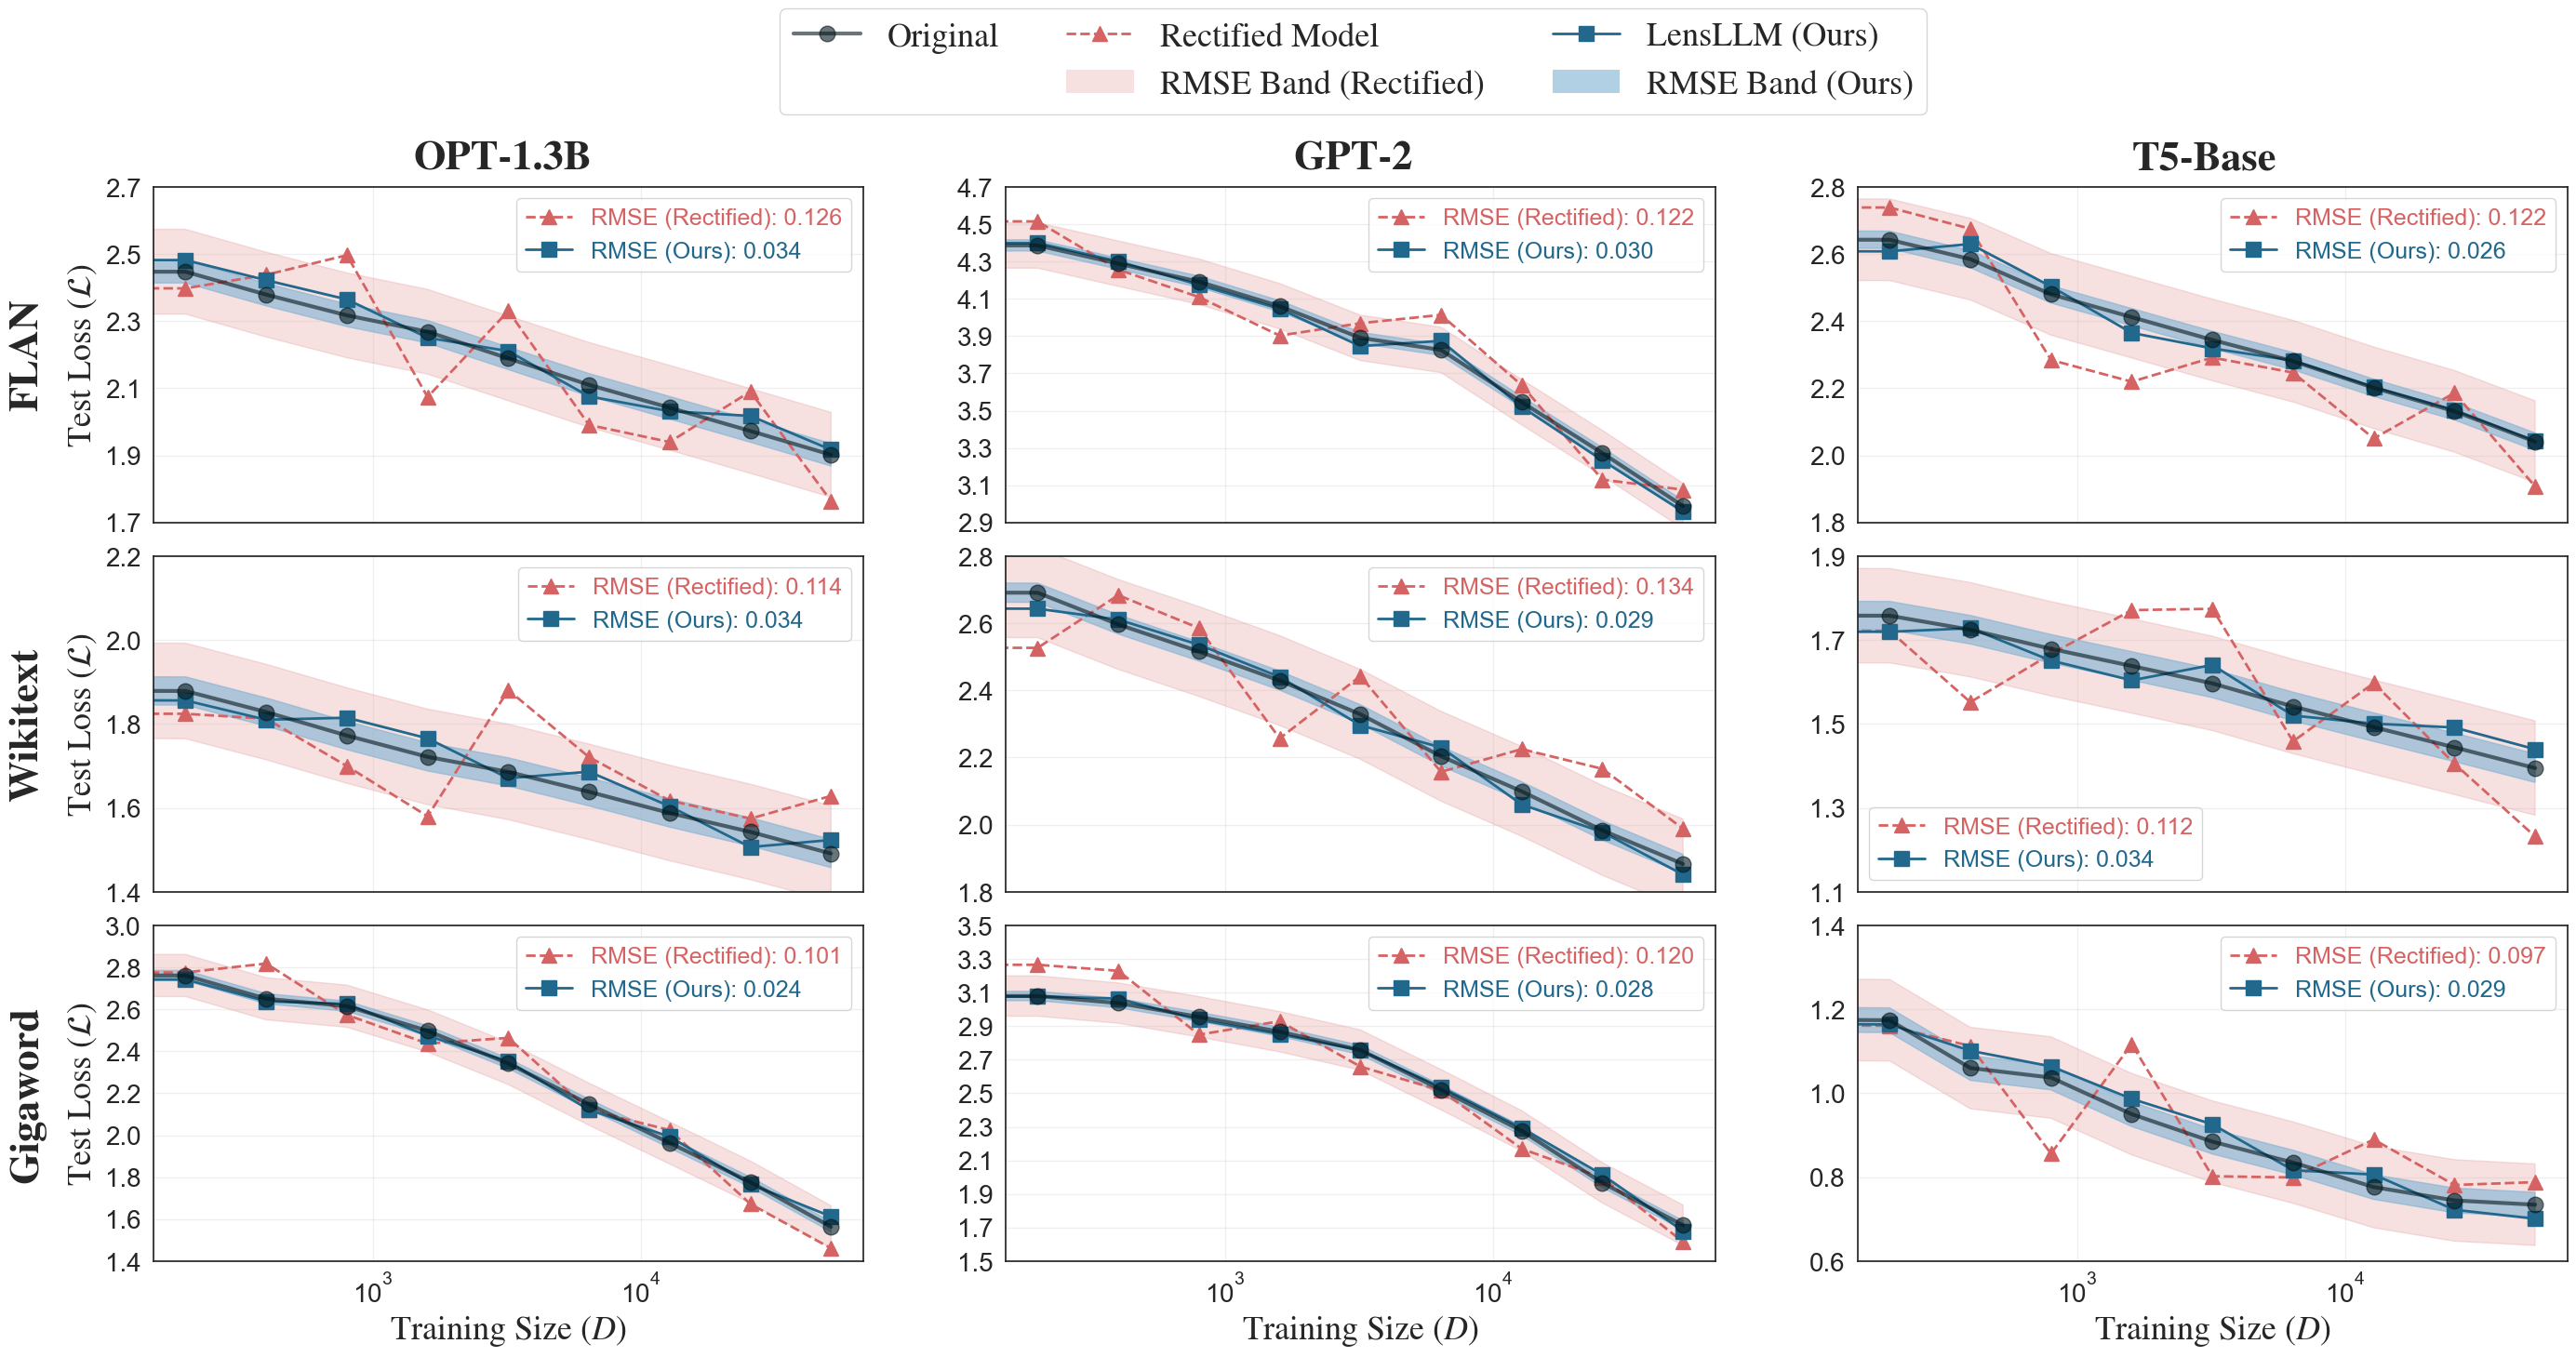

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import seaborn as sns
from matplotlib import rcParams
# Set the global font family to Nimbus Roman
rcParams['axes.titlesize'] = 24   # Title font size
rcParams['axes.labelsize'] = 22   # Axis label font size
rcParams['xtick.labelsize'] = 20  # X-tick label font size
rcParams['ytick.labelsize'] = 20  # Y-tick label font size
rcParams['font.size'] = 24
rcParams['font.family'] = 'DejaVu Sans'
rcParams['mathtext.fontset'] = 'stix'
# rcParams['font.family'] = 'Nimbus Roman'

def adjust_saturation(color, saturation=0.75):
    r, g, b, a = to_rgba(color)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    r = gray + saturation * (r - gray)
    g = gray + saturation * (g - gray)
    b = gray + saturation * (b - gray)
    return (r, g, b, a)

def adjust_lightness(color, amount=0.5):
    """
    Adjust the lightness of the given color. 
    An amount less than 1 will darken the color, and an amount greater than 1 will lighten the color.

    Parameters:
    color (str or tuple): Matplotlib color string or RGBA tuple.
    amount (float): Factor to adjust the lightness. Default is 0.5 (darken).

    Returns:
    tuple: Adjusted color in RGBA format.
    """
    r, g, b, a = to_rgba(color)
    # Blend with black
    r = r * amount
    g = g * amount
    b = b * amount
    return (r, g, b, a)

def plot_dataset_comparison(ax, model_name, dataset_name, dataset_data, steps):
    """
    Create a plot for a single dataset and model combination with fixed y-axis limits.
    """
    sns.set_theme(style="whitegrid")
    
    # Calculate MSE
    mse_fitted = calculate_mse(dataset_data['test'][model_name], dataset_data['ntk'][model_name])
    mse_rectified = calculate_mse(dataset_data['test'][model_name], dataset_data['rec'][model_name])
    rmse_fitted = np.sqrt(calculate_mse(dataset_data['test'][model_name], dataset_data['ntk'][model_name]))
    rmse_rectified = np.sqrt(calculate_mse(dataset_data['test'][model_name], dataset_data['rec'][model_name]))
    
    # Convert predictions to numpy arrays
    ntk_pred = np.array(dataset_data['ntk'][model_name])
    rec_pred = np.array(dataset_data['rec'][model_name])
    test_values = np.array(dataset_data['test'][model_name])
    
    # Set fixed y-axis limits
    ymax = round(np.max(np.concatenate([rec_pred[1:], ntk_pred[1:]])) + 0.1, 1)
    ymin = round(np.min(np.concatenate([rec_pred[1:], ntk_pred[1:]])) - 0.1, 1)
    
    ax.set_ylim(ymin, ymax)
    
    # Set y-ticks at 0.1 intervals
    yticks = np.arange(ymin, ymax + 0.2, 0.2)
    ax.set_yticks(yticks)
    
    # Calculate RMSE for both models
    rec_rmse = np.sqrt(np.mean((rec_pred - test_values) ** 2))  # RMSE for rectified model
    our_rmse = np.sqrt(np.mean((ntk_pred - test_values) ** 2))  # RMSE for our model

    # Define constant error bands based on RMSE
    rec_upper_bound = test_values + rec_rmse
    rec_lower_bound = test_values - rec_rmse

    our_upper_bound = test_values + our_rmse
    our_lower_bound = test_values - our_rmse

    # Plot the rectified model predictions
    ax.plot(steps, rec_pred, color=colors['rec'], marker='^', linestyle='--', linewidth=2, markersize=12, label=f"RMSE (Rectified): {rmse_rectified:.3f}")

    # Plot your model predictions
    ax.plot(steps, ntk_pred, color=colors['ntk'], marker='s', linestyle='-', linewidth=2, markersize=12, label=f"RMSE (Ours): {rmse_fitted:.3f}")
    
    # Plot the original curve
    ax.plot(steps, test_values, color=colors['test'], marker='o', alpha=0.6, linestyle='-', linewidth=3, markersize=12)#, label='Original')

    # Add RMSE-based error bands
    ax.fill_between(steps, rec_lower_bound, rec_upper_bound, color=error_band_colors['rec'], alpha=0.3)#, label=f'RMSE Band (Rectified, ±{rec_rmse:.2f})')
    ax.fill_between(steps, our_lower_bound, our_upper_bound, color=error_band_colors['ntk'], alpha=0.6)#, label=f'RMSE Band (Our Model, ±{our_rmse:.2f})')
    
    
    ax.legend(labelcolor='linecolor', fontsize=18)
    # ax.set_title(f"{dataset_name},{model_name}")
    
    # Customize axes
    ax.set_xscale('log')
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    # plt.ylim(1.8, 3.0)  # Adjust as necessary

    # Add legend and layout tweaks
    # plt.legend(loc='upper right', fontsize=18, frameon=False)
    ax.grid(True, alpha=0.3)

    
# Set global style parameters
sns.set_theme(style="white")
sns.set_context("notebook", font_scale=1.1)
    
# Get the training steps
steps = [0, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200]

fig, axes = plt.subplots(3, 3, figsize=(30, 15), sharex=True, sharey=False)

# Define colors
colors = {
    'test': '#05191e',  # Dark Steel Blue for "Original"
    'rec': '#d66363',  # Darker, warm orange for "Rectified Model"
    'ntk': '#22688c',  # Darker Slate Blue for "Our Model"
}

error_band_colors = {
    'rec': '#e29b9b',  # Softer orange for rectified error band
    'ntk': '#7fb2d3',  # Softer blue for our error band
}
# colors['rec'] = adjust_lightness(error_band_colors['rec'], 0.6)
# colors['ntk'] = adjust_lightness(error_band_colors['ntk'], 0.6)
    
# Flatten axes array for easy indexing
axes = axes.flatten()
# Create separate plots for each dataset and model combination
for i, (dataset_name, dataset_data) in enumerate(datasets_data.items()):
    # Get models for this dataset
    models = list(dataset_data['test'].keys())

    # Create plot for each model
    for j, model_name in enumerate(models):
        ax = axes[i * 3 + j]
        # plt.figure(figsize=(12, 8))
        plot_dataset_comparison(ax, model_name, dataset_name, dataset_data, steps)
        if i == 2:
            ax.set_xlabel('Training Size ($D$)', fontsize=26, fontfamily='Nimbus Roman')
        if j == 0:
            ax.set_ylabel('Test Loss ($\mathcal{L}$)', fontsize=26, fontfamily='Nimbus Roman')

            
# Add column headers (model names)
for j, model_name in enumerate(models):
    fig.text(
        0.25 + j * 0.305, 0.90, model_name, ha='center', va='center', fontsize=32, fontweight='bold', fontfamily='Nimbus Roman'
    )

# Add row headers (dataset names)
for i, dataset_name in enumerate(datasets_data):
    fig.text(
        0.08, 0.76 - i * 0.265, dataset_name, ha='center', va='center', fontsize=32, fontweight='bold', rotation=90, fontfamily='Nimbus Roman'
    )

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0], [0], color=colors['test'], marker='o', alpha=0.6, linestyle='-', linewidth=3, markersize=12, label='Original'),
    Patch(facecolor='#FFFFFF', edgecolor='none', alpha=0.3, label=''),
    Line2D([0], [0], color=colors['rec'], marker='^', linestyle='--', linewidth=2, markersize=12, label='Rectified Model'),
    Patch(facecolor=error_band_colors['rec'], edgecolor='none', alpha=0.3, label='RMSE Band (Rectified)'),
    Line2D([0], [0], color=colors['ntk'], marker='s', linestyle='-', linewidth=2, markersize=12, label='LensLLM (Ours)'),
    Patch(facecolor=error_band_colors['ntk'], edgecolor='none', alpha=0.6, label='RMSE Band (Ours)'),
]

# Add global legend below the subplots
rcParams['font.family'] = 'Nimbus Roman'
fig.legend(
    handles=legend_elements,
    loc='lower center',
    # bbox_to_anchor=(0.5, -0.05),
    bbox_to_anchor=(0.555, 0.92),
    fontsize=26,
    ncol=3,
    frameon=True,
)

plt.subplots_adjust(right=0.99, hspace=0.1)  # Adjusted spacing

plt.savefig('combined_plots.png', 
            dpi=120,
            facecolor='white',
            edgecolor='none',
            bbox_inches='tight') 

plt.show()